# Part 3 — EDA: BTS Multi-Year Flights (2023–2025)

**Dataset:** ~20.6M domestic flights scraped from BTS (Jan 2023 – Dec 2025)  
**Goal:** Understand delay patterns across years, carriers, routes, and seasons before feature engineering.

In [1]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import config

config.assert_data_exists()
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

## 1. Load Data

In [2]:
# Adjust nrows=None to load the full dataset (may take several minutes)
df = config.load_bts_flights()
print(f"Shape: {df.shape}")
df.head()

Shape: (10146889, 23)


,YEAR,MONTH,DAY_OF_WEEK,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_DELAY_NEW,CRS_ARR_TIME,ARR_DELAY_NEW,ARR_DEL15,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,2023,1,1,1/2/2023 12:00:00 AM,9E,N131EV,4721,BNA,JFK,1400,0.0,1726,0.0,0.0,0.0,0.0,146.0,765.0,NaN,NaN,NaN,NaN,NaN
1,2023,1,1,1/2/2023 12:00:00 AM,9E,N131EV,4721,JFK,BNA,1030,0.0,1215,0.0,0.0,0.0,0.0,165.0,765.0,NaN,NaN,NaN,NaN,NaN
2,2023,1,1,1/2/2023 12:00:00 AM,9E,N131EV,5041,JFK,IND,1859,0.0,2128,0.0,0.0,0.0,0.0,149.0,665.0,NaN,NaN,NaN,NaN,NaN
3,2023,1,1,1/2/2023 12:00:00 AM,9E,N131EV,5479,BGR,JFK,500,0.0,700,0.0,0.0,0.0,0.0,120.0,382.0,NaN,NaN,NaN,NaN,NaN
4,2023,1,1,1/2/2023 12:00:00 AM,9E,N133EV,4711,ATL,XNA,1215,0.0,1317,0.0,0.0,0.0,0.0,122.0,589.0,NaN,NaN,NaN,NaN,NaN


## 2. Schema & Dtypes

In [3]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 10146889 entries, 0 to 10146888
Data columns (total 23 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY_OF_WEEK          int64  
 3   FL_DATE              str    
 4   OP_CARRIER           str    
 5   TAIL_NUM             str    
 6   OP_CARRIER_FL_NUM    int64  
 7   ORIGIN               str    
 8   DEST                 str    
 9   CRS_DEP_TIME         int64  
 10  DEP_DELAY_NEW        float64
 11  CRS_ARR_TIME         int64  
 12  ARR_DELAY_NEW        float64
 13  ARR_DEL15            float64
 14  CANCELLED            float64
 15  DIVERTED             float64
 16  CRS_ELAPSED_TIME     float64
 17  DISTANCE             float64
 18  CARRIER_DELAY        float64
 19  WEATHER_DELAY        float64
 20  NAS_DELAY            float64
 21  SECURITY_DELAY       float64
 22  LATE_AIRCRAFT_DELAY  float64
dtypes: float64(12), int64(6), str(5)
memory u

In [4]:
df.describe(include="all")

,YEAR,MONTH,DAY_OF_WEEK,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_DELAY_NEW,CRS_ARR_TIME,ARR_DELAY_NEW,ARR_DEL15,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
count,1.014689e+07,1.014689e+07,1.014689e+07,10146889,10146889,10146889,1.014689e+07,10146889,10146889,1.014689e+07,1.014689e+07,1.014689e+07,1.014689e+07,1.014689e+07,10146889.0,10146889.0,1.014689e+07,1.014689e+07,2.135351e+06,2.135351e+06,2.135351e+06,2.135351e+06,2.135351e+06
unique,NaN,NaN,NaN,547,15,6142,NaN,351,351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,6/17/2024 12:00:00 AM,WN,N488HA,NaN,ATL,ATL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,21117,2125547,4995,NaN,499009,499072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.023335e+03,5.591497e+00,3.985275e+00,NaN,NaN,NaN,2.348471e+03,NaN,NaN,1.330041e+03,1.580079e+01,1.488774e+03,1.579018e+01,2.104440e-01,0.0,0.0,1.463803e+02,8.346189e+02,2.460506e+01,3.995086e+00,1.306167e+01,1.464654e-01,2.830035e+01
std,4.721376e-01,3.275319e+00,2.002094e+00,NaN,NaN,NaN,1.591619e+03,NaN,NaN,4.957743e+02,5.493924e+01,5.241145e+02,5.481728e+01,4.076240e-01,0.0,0.0,7.294003e+01,5.977517e+02,7.652842e+01,3.315128e+01,3.189844e+01,3.609356e+00,6.309698e+01
min,2.023000e+03,1.000000e+00,1.000000e+00,NaN,NaN,NaN,1.000000e+00,NaN,NaN,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,-5.000000e+00,2.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.023000e+03,3.000000e+00,2.000000e+00,NaN,NaN,NaN,1.068000e+03,NaN,NaN,9.070000e+02,0.000000e+00,1.100000e+03,0.000000e+00,0.000000e+00,0.0,0.0,9.300000e+01,3.990000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.023000e+03,5.000000e+00,4.000000e+00,NaN,NaN,NaN,2.086000e+03,NaN,NaN,1.321000e+03,0.000000e+00,1.515000e+03,0.000000e+00,0.000000e+00,0.0,0.0,1.300000e+02,6.800000e+02,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00
75%,2.024000e+03,8.000000e+00,6.000000e+00,NaN,NaN,NaN,3.434000e+03,NaN,NaN,1.740000e+03,9.000000e+00,1.926000e+03,1.000000e+01,0.000000e+00,0.0,0.0,1.770000e+02,1.069000e+03,2.200000e+01,0.000000e+00,1.700000e+01,0.000000e+00,3.300000e+01


## 3. Missing Values

In [5]:
miss = df.isnull().sum()
miss[miss > 0].sort_values(ascending=False)

CARRIER_DELAY          8011538
NAS_DELAY              8011538
WEATHER_DELAY          8011538
SECURITY_DELAY         8011538
LATE_AIRCRAFT_DELAY    8011538
ARR_DEL15                    1
ARR_DELAY_NEW                1
dtype: int64

## 4. Target Distribution

ARR_DEL15
on-time    0.789556
delayed    0.210444
Name: proportion, dtype: float64


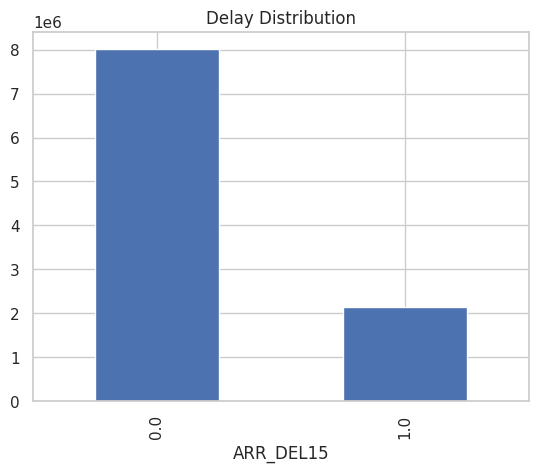

In [6]:
target_col = "ARR_DEL15"  # 1 = arrival delayed ≥15 min

print(df[target_col].value_counts(normalize=True).rename({0: "on-time", 1: "delayed"}))
df[target_col].value_counts().plot(kind="bar", title="Delay Distribution")
plt.show()

## 5. Delay Rate by Year

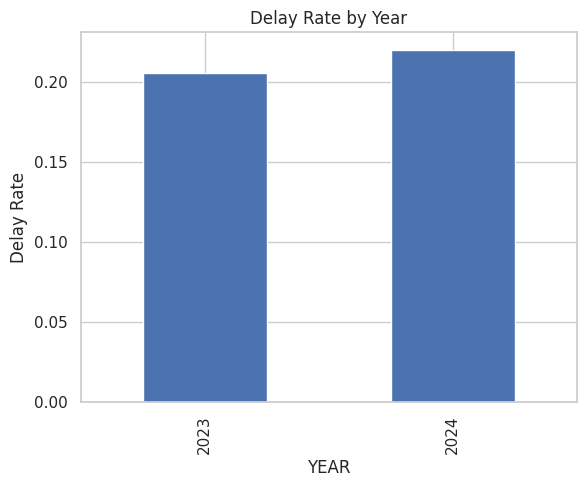

In [7]:
year_col = "YEAR"

df.groupby(year_col)[target_col].mean().plot(
    kind="bar", title="Delay Rate by Year", ylabel="Delay Rate"
)
plt.show()

## 6. Delay Rate by Month

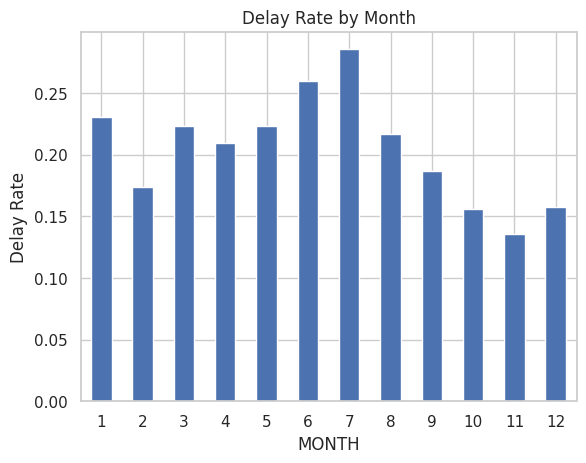

In [8]:
month_col = "MONTH"

df.groupby(month_col)[target_col].mean().plot(
    kind="bar", title="Delay Rate by Month", ylabel="Delay Rate"
)
plt.xticks(rotation=0)
plt.show()

## 7. Delay Rate by Carrier

                mean    count
OP_CARRIER                   
F9          0.310473   271296
B6          0.297552   387307
NK          0.277179   388587
AA          0.248139  1406480
G4          0.242225   172963
WN          0.221451  2125547
HA          0.219896   118033
UA          0.207692  1080457
AS          0.206513   355610
MQ          0.202003   357837
OH          0.180909   294767
OO          0.173654  1008000
DL          0.167156  1459228
9E          0.144848   294495
YX          0.130299   426281


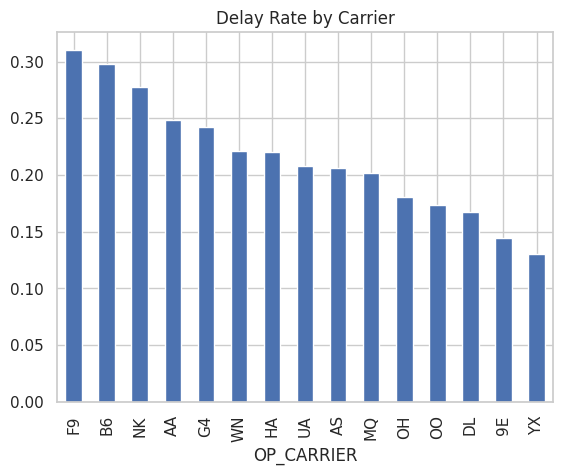

In [9]:
carrier_col = "OP_CARRIER"

carrier_stats = (
    df.groupby(carrier_col)[target_col]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)
print(carrier_stats)
carrier_stats["mean"].plot(kind="bar", title="Delay Rate by Carrier")
plt.show()

## 8. Top Routes by Volume and Delay Rate

In [10]:
origin_col = "ORIGIN"
dest_col   = "DEST"

df["route"] = df[origin_col] + "→" + df[dest_col]
route_stats = (
    df.groupby("route")[target_col]
    .agg(["mean", "count"])
    .query("count > 1000")
    .sort_values("mean", ascending=False)
)
print("Top 20 most-delayed routes (min 1000 flights):")
print(route_stats.head(20))

Top 20 most-delayed routes (min 1000 flights):
             mean  count
route                   
BDL→SJU  0.464005   1528
FLL→LAS  0.449761   1254
SJU→BDL  0.445102   1521
RIC→MCO  0.409258   1361
FLL→RIC  0.408747   1189
CLT→SFO  0.383604   2281
LAS→FLL  0.382470   1255
SJU→PHL  0.381181   2083
FLL→PIT  0.380300   1533
FLL→AUS  0.376438   1825
HNL→PDX  0.373991   1115
FLL→RDU  0.373534   2131
MCO→LAS  0.372951   1952
DFW→SFO  0.367198   5768
FLL→MCO  0.365772   2086
FLL→IND  0.365176   1476
PHL→SJU  0.365064   2101
MIA→SFO  0.364491   2022
BET→ANC  0.360718   1059
FLL→CLE  0.356828   1816


## 9. Departure Time Distribution

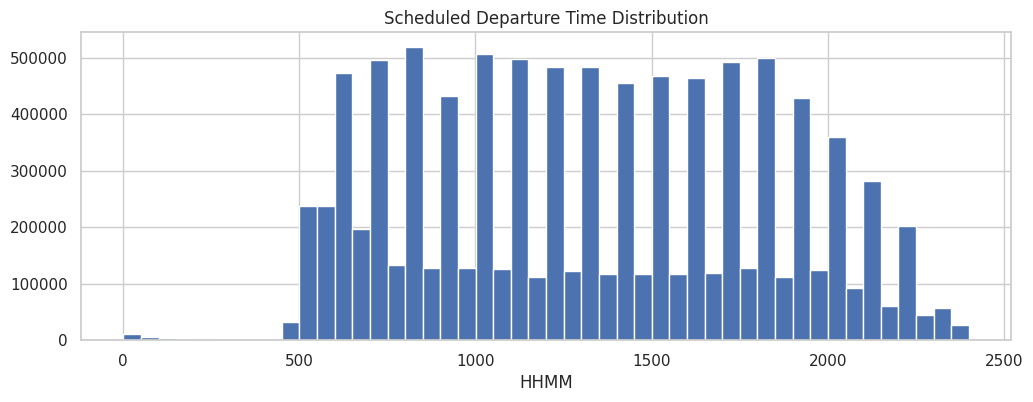

In [11]:
# CRS_DEP_TIME is typically HHMM format
dep_time_col = "CRS_DEP_TIME"

df[dep_time_col].hist(bins=48, figsize=(12, 4))
plt.title("Scheduled Departure Time Distribution")
plt.xlabel("HHMM")
plt.show()

## 10. Summary

TODO: Fill in key findings after running cells above.

- Dataset shape:
- Delay rate overall:
- Peak delay months:
- Most-delayed carrier:
- Key missing value columns: